# ClosetAI · Cluster di stile nel guardaroba
## K-means non supervisionato + PCA per la visualizzazione

**Stato nel prodotto:** esperimento di ricerca, non collegato alla
UI. K-means non “scopre la verità”: crea gruppi secondo le feature e
la distanza che scegliamo.

In [1]:
# Trova la radice del repository anche se Jupyter parte da una sottocartella.
from pathlib import Path

def find_project_root(start: Path | None = None) -> Path:
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "backend" / "pyproject.toml").is_file() and (candidate / "ml").is_dir():
            return candidate
    raise FileNotFoundError("Radice di ClosetAI non trovata")

ROOT = find_project_root()
SEED = 42
print(f"Repository: {ROOT}")

Repository: C:\devel\closet-ai


In [2]:
# Dataset sintetico deterministico usato SOLO per l'esperimento didattico.
# In produzione queste righe dovrebbero arrivare dal wear log consensuale.
import numpy as np
import pandas as pd

CATEGORIES = ["t-shirt", "camicia", "felpa", "maglione", "giacca", "cappotto",
              "jeans", "pantaloni", "shorts", "gonna", "vestito", "scarpe"]
COLORS = ["nero", "bianco", "blu", "rosso", "verde", "beige", "grigio", "marrone"]
WEAR_PRIOR = {"t-shirt": 38, "camicia": 20, "felpa": 24, "maglione": 18,
              "giacca": 12, "cappotto": 8, "jeans": 34, "pantaloni": 24,
              "shorts": 12, "gonna": 10, "vestito": 8, "scarpe": 30}
PRICE_RANGE = {"t-shirt": (10, 40), "camicia": (25, 90), "felpa": (25, 80),
               "maglione": (40, 130), "giacca": (60, 220), "cappotto": (120, 400),
               "jeans": (40, 140), "pantaloni": (30, 120), "shorts": (15, 60),
               "gonna": (25, 100), "vestito": (45, 180), "scarpe": (50, 180)}

def generate_wardrobe(n=800, seed=SEED):
    rng = np.random.default_rng(seed)
    rows = []
    for _ in range(n):
        category = str(rng.choice(CATEGORIES))
        low, high = PRICE_RANGE[category]
        price = float(rng.uniform(low, high))
        days_owned = int(rng.integers(20, 1100))
        month = int(rng.integers(0, 12))
        years = days_owned / 365
        price_factor = 1 - 0.1 * (price - low) / max(high - low, 1)
        # Outcome didattico a 90 giorni. Questi coefficienti non sono
        # osservazioni reali: sono dichiarati per rendere l'esperimento
        # riproducibile senza creare un dataset degenere.
        occasion_risk = {"cappotto": 1.55, "vestito": 1.25, "giacca": .85,
                         "gonna": .65, "camicia": .45}.get(category, 0.0)
        off_season = (
            1.35 if category in {"cappotto", "maglione", "giacca"} and month in {4, 5, 6, 7, 8}
            else .9 if category in {"shorts", "t-shirt"} and month in {10, 11, 0, 1, 2}
            else 0.0
        )
        price_risk = .55 * ((price - low) / max(high - low, 1))
        logit = -2.25 + occasion_risk + off_season + price_risk + rng.normal(0, .20)
        ghost_probability = 1 / (1 + np.exp(-logit))
        ghost_outcome = int(rng.random() < ghost_probability)

        if ghost_outcome:
            wear = int(rng.integers(0, 2))
        else:
            wear = WEAR_PRIOR[category] * years * price_factor * rng.normal(1, 0.25)
        rows.append({
            "category": category, "color": str(rng.choice(COLORS)),
            "price_eur": round(price, 2), "days_owned": days_owned,
            "purchase_month": month, "wear_count": max(0, int(round(wear))),
            "is_ghost": ghost_outcome,
        })
    data = pd.DataFrame(rows)
    return data

df = generate_wardrobe()
print(df.shape, "ghost rate", f"{df['is_ghost'].mean():.1%}")
df.head()

(800, 7) ghost rate 24.2%


,category,color,price_eur,days_owned,purchase_month,wear_count,is_ghost
0,camicia,verde,53.53,855,5,1,1
1,scarpe,bianco,148.95,794,9,74,0
2,scarpe,marrone,133.70,454,9,38,0
3,t-shirt,rosso,34.83,318,7,40,0
4,vestito,bianco,150.08,840,2,1,1


In [3]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat = ["category", "color"]
num = ["price_eur", "days_owned", "wear_count"]
prep = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
    ("num", StandardScaler(), num),
])
embedded = prep.fit_transform(df[cat + num])

rows = []
for k in range(2, 9):
    candidate = KMeans(n_clusters=k, random_state=SEED, n_init=20).fit(embedded)
    rows.append({"k": k, "inertia": candidate.inertia_, "silhouette": silhouette_score(embedded, candidate.labels_)})
diagnostics = pd.DataFrame(rows)
diagnostics

C:\devel\closet-ai\backend\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\devel\closet-ai\backend\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,k,inertia,silhouette
0,2,2942.809185,0.206452
1,3,2409.421768,0.227450
2,4,2119.232125,0.186566
3,5,2010.644580,0.163968
4,6,1913.469741,0.148843
5,7,1844.825787,0.134852
6,8,1780.405887,0.123539


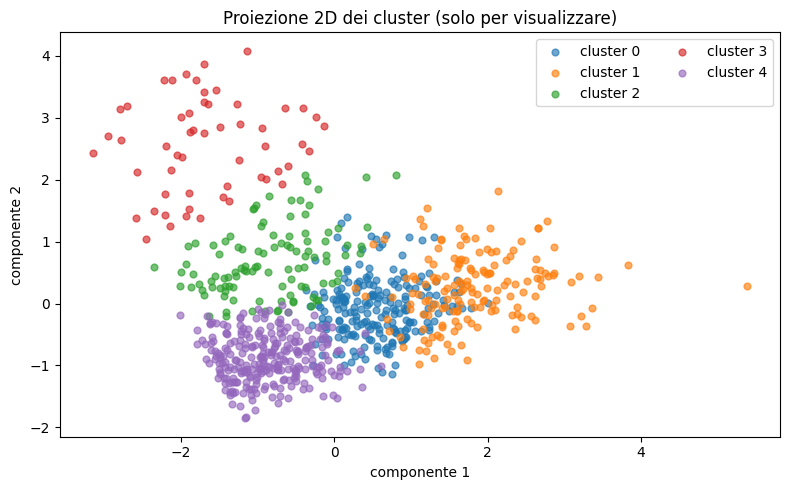

In [4]:
# Scegliamo K=5 come compromesso didattico: non è una verità naturale.
K = 5
kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=20).fit(embedded)
df["cluster"] = kmeans.labels_

# TruncatedSVD gestisce direttamente la matrice sparsa one-hot.
projection = TruncatedSVD(n_components=2, random_state=SEED).fit_transform(embedded)
plt.figure(figsize=(8, 5))
for cluster in range(K):
    mask = df["cluster"] == cluster
    plt.scatter(projection[mask, 0], projection[mask, 1], s=24, alpha=.65, label=f"cluster {cluster}")
plt.xlabel("componente 1"); plt.ylabel("componente 2")
plt.title("Proiezione 2D dei cluster (solo per visualizzare)")
plt.legend(ncol=2); plt.tight_layout(); plt.show()

In [5]:
# Profilare i cluster è indispensabile: un numero da solo non ha senso.
profile = df.groupby("cluster").agg(
    n=("category", "size"),
    categoria_top=("category", lambda s: s.mode().iloc[0]),
    colore_top=("color", lambda s: s.mode().iloc[0]),
    prezzo_medio=("price_eur", "mean"),
    utilizzi_medi=("wear_count", "mean"),
    giorni_medi=("days_owned", "mean"),
).round(1)
profile

,n,categoria_top,colore_top,prezzo_medio,utilizzi_medi,giorni_medi
cluster,,,,,,
0,217,gonna,beige,62.8,21.3,775.4
1,157,jeans,nero,70.5,64.7,816.4
2,107,giacca,nero,157.6,8.7,515.5
3,55,cappotto,verde,301.3,6.3,544.3
4,264,gonna,marrone,67.9,9.2,234.5


### Cosa dire all'esame

- K-means minimizza la distanza interna ai cluster; non usa etichette.
- Scaling e one-hot encoding definiscono implicitamente cosa conta
  come “vicino”. Cambiandoli, cambiano i cluster.
- Silhouette aiuta a confrontare K, ma va letta insieme alla
  comprensibilità dei profili.
- La proiezione 2D perde informazione ed è solo una visualizzazione.